# Imports and Functions

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Function to compute sensitivity results
def compute_results(concatenated_matrix):
    """
    Compute sensitivity results from concatenated matrix.
    """
    if concatenated_matrix.ndim != 3:
        raise ValueError("The input matrix must be 3-dimensional.")
    
    factors_num, samples_num, scenarios_num = concatenated_matrix.shape
    S = np.zeros((factors_num, scenarios_num))

    for factor_index in range(factors_num):
        result = concatenated_matrix[factor_index, :, :]
        U = np.sum(result[:, 0] * result[:, 1]) / samples_num
        UT = np.sum(result[:, 0] * result[:, 2]) / samples_num
        F0 = np.mean(result[:, 0])
        V = np.sum((result[:, 0] - F0) ** 2) / samples_num

        S[factor_index, 0] = 1 - (UT - F0 ** 2) / V  # Total effect
        S[factor_index, 1] = (U - F0 ** 2) / V       # Main effect
        S[factor_index, 2] = S[factor_index, 0] - S[factor_index, 1]  # Interactions

    return S

In [2]:
def process_output(output_type):
    """
    Process each output type, compute sensitivity, and generate bar plots with corrected titles.
    """
    # Map output types to more descriptive titles
    title_mapping = {
        'total_outflow': 'Total Runoff Volume',
        'max_outflow': 'Peak Runoff Discharge'
    }
    SA_reference_param = title_mapping.get(output_type, output_type.replace('_', ' ').title())

    VB_SA_result_dic = {}
    fig_output_path = os.path.join(fig_output_path_base, output_type)
    os.makedirs(fig_output_path, exist_ok=True)

    # Process each event
    for event in EVENTS_L:
        date = '_'.join([event[:4], event[4:6], event[6:]])
        sim_dir = os.path.join(
            r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis",
            date, 'pickles', output_type
        )

        if not os.path.exists(sim_dir):
            print(f"Directory does not exist: {sim_dir}")
            continue

        concatenated_matrices = None
        for file_name in os.listdir(sim_dir):
            if file_name.startswith("VB_with_coxbox_") and file_name.endswith(f"_{output_type}.pickle"):
                with open(os.path.join(sim_dir, file_name), 'rb') as f:
                    sensitivity_results = np.array(pickle.load(f))
                    concatenated_matrices = (
                        sensitivity_results
                        if concatenated_matrices is None
                        else np.concatenate((concatenated_matrices, sensitivity_results), axis=1)
                    )

        if concatenated_matrices is not None:
            S = compute_results(concatenated_matrices)
            sensitivity_results_df = pd.DataFrame(
                S, columns=['Total effect', 'Main effect', 'Interactions importance'], index=parameters
            )
            VB_SA_result_dic[date] = sensitivity_results_df
            print(f"Processed {date}: {concatenated_matrices.shape[1]} iterations")
        else:
            print(f"No valid data found for {date}. Skipping computation.")

    # Collect data for bar plots
    events = list(VB_SA_result_dic.keys())
    sensitivity_results_all_events = {event: VB_SA_result_dic[event] for event in events}

    median_total_effects = {
        param: np.median([sensitivity_results_all_events[event].loc[param, 'Total effect'] for event in events])
        for param in parameters
    }
    sorted_parameters = sorted(parameters, key=lambda x: median_total_effects[x], reverse=True)
    updated_labels = [parameter_label_mapping[param] for param in sorted_parameters]

    # Generate bar plot
    fig, ax = plt.subplots(figsize=(22, 12))
    index = np.arange(len(sorted_parameters))
    bar_width = 0.2
    event_colors = plt.cm.get_cmap('tab10', len(events))
    legend_colors = []

    for i, event in enumerate(events):
        sensitivity_results_df = sensitivity_results_all_events[event]
        adjusted_interactions = sensitivity_results_df['Interactions importance'].clip(lower=0)
        event_positions = index + i * bar_width

        for j, param in enumerate(sorted_parameters):
            main_effect_value = max(sensitivity_results_df.loc[param, 'Main effect'], 0)
            interaction_value = max(adjusted_interactions[param], 0)
            color = event_colors(i)

            ax.bar(event_positions[j], main_effect_value, bar_width, color=color, edgecolor='black', alpha=0.7)
            ax.bar(event_positions[j], interaction_value, bar_width, bottom=main_effect_value,
                   color=color, edgecolor='black', hatch='//', alpha=0.7)

        legend_colors.append(Patch(facecolor=color))

    # Add legends for main and interaction effects
    legend_main_patch = Patch(facecolor='white', edgecolor='black', label='Main Effect')
    legend_interaction_patch = Patch(facecolor='white', hatch='//', edgecolor='black', label='Interactions Importance')
    legend_main_interaction = ax.legend(
        handles=[legend_main_patch, legend_interaction_patch], fontsize=18, loc='upper left', bbox_to_anchor=(0.72, 0.98)
    )
    ax.add_artist(legend_main_interaction)

    # Add legend for event dates
    formatted_dates = [f"{event.split('_')[2]}/{event.split('_')[1]}/{event.split('_')[0]}" for event in events]
    legend_dates = ax.legend(
        handles=legend_colors, labels=formatted_dates, fontsize=18, loc='upper left', bbox_to_anchor=(0.72, 0.79)
    )
    ax.add_artist(legend_dates)

    # Set titles and labels
    ax.set_title(f'{SA_reference_param} Sensitivity Analysis', fontsize=30, fontweight='bold')
    ax.set_ylabel('Total Effect', fontsize=24, fontweight='bold')
    ax.set_xticks(index + bar_width * (len(events) / 2 - 0.5))
    ax.set_xticklabels(updated_labels, rotation=45, fontsize=26, ha='right')
    ax.tick_params(axis='both', labelsize=24)
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.savefig(os.path.join(fig_output_path, f'VB_barplot_{output_type}.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Collect data for combined plot
    combined_data[output_type] = {
        param: [
            sensitivity_results_all_events[event].loc[param, 'Total effect']
            for event in events
        ]
        for param in sorted_parameters
    }


# Parameters

In [3]:
EVENTS_L = ['20120113', '20160108', '20180125', '20191213']
output_types = ['total_outflow', 'max_outflow']
fig_output_path_base = r'D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\VB'
parameters = [
    'Impervious Surface', 
    'Water Storage', 
    'Manning Roughness Coefficient',
    'No Storage Impervious Surface', 
    'CN (Infiltartion)', 
    'Rain Intensity Distribution'
]
parameter_label_mapping = {
    'Rain Intensity Distribution': 'RID (λ)',
    'Impervious Surface': 'IMP',
    'Water Storage': 'Dstore',
    'CN (Infiltartion)': 'CN',
    'Manning Roughness Coefficient': 'N',
    'No Storage Impervious Surface': 'PctZero'
}
colors = {'total_outflow': 'blue', 'max_outflow': 'red'}

# Prepare combined data container
combined_data = {}

Processed 2012_01_13: 10000 iterations
Processed 2016_01_08: 10000 iterations
Processed 2018_01_25: 10000 iterations
Processed 2019_12_13: 10000 iterations


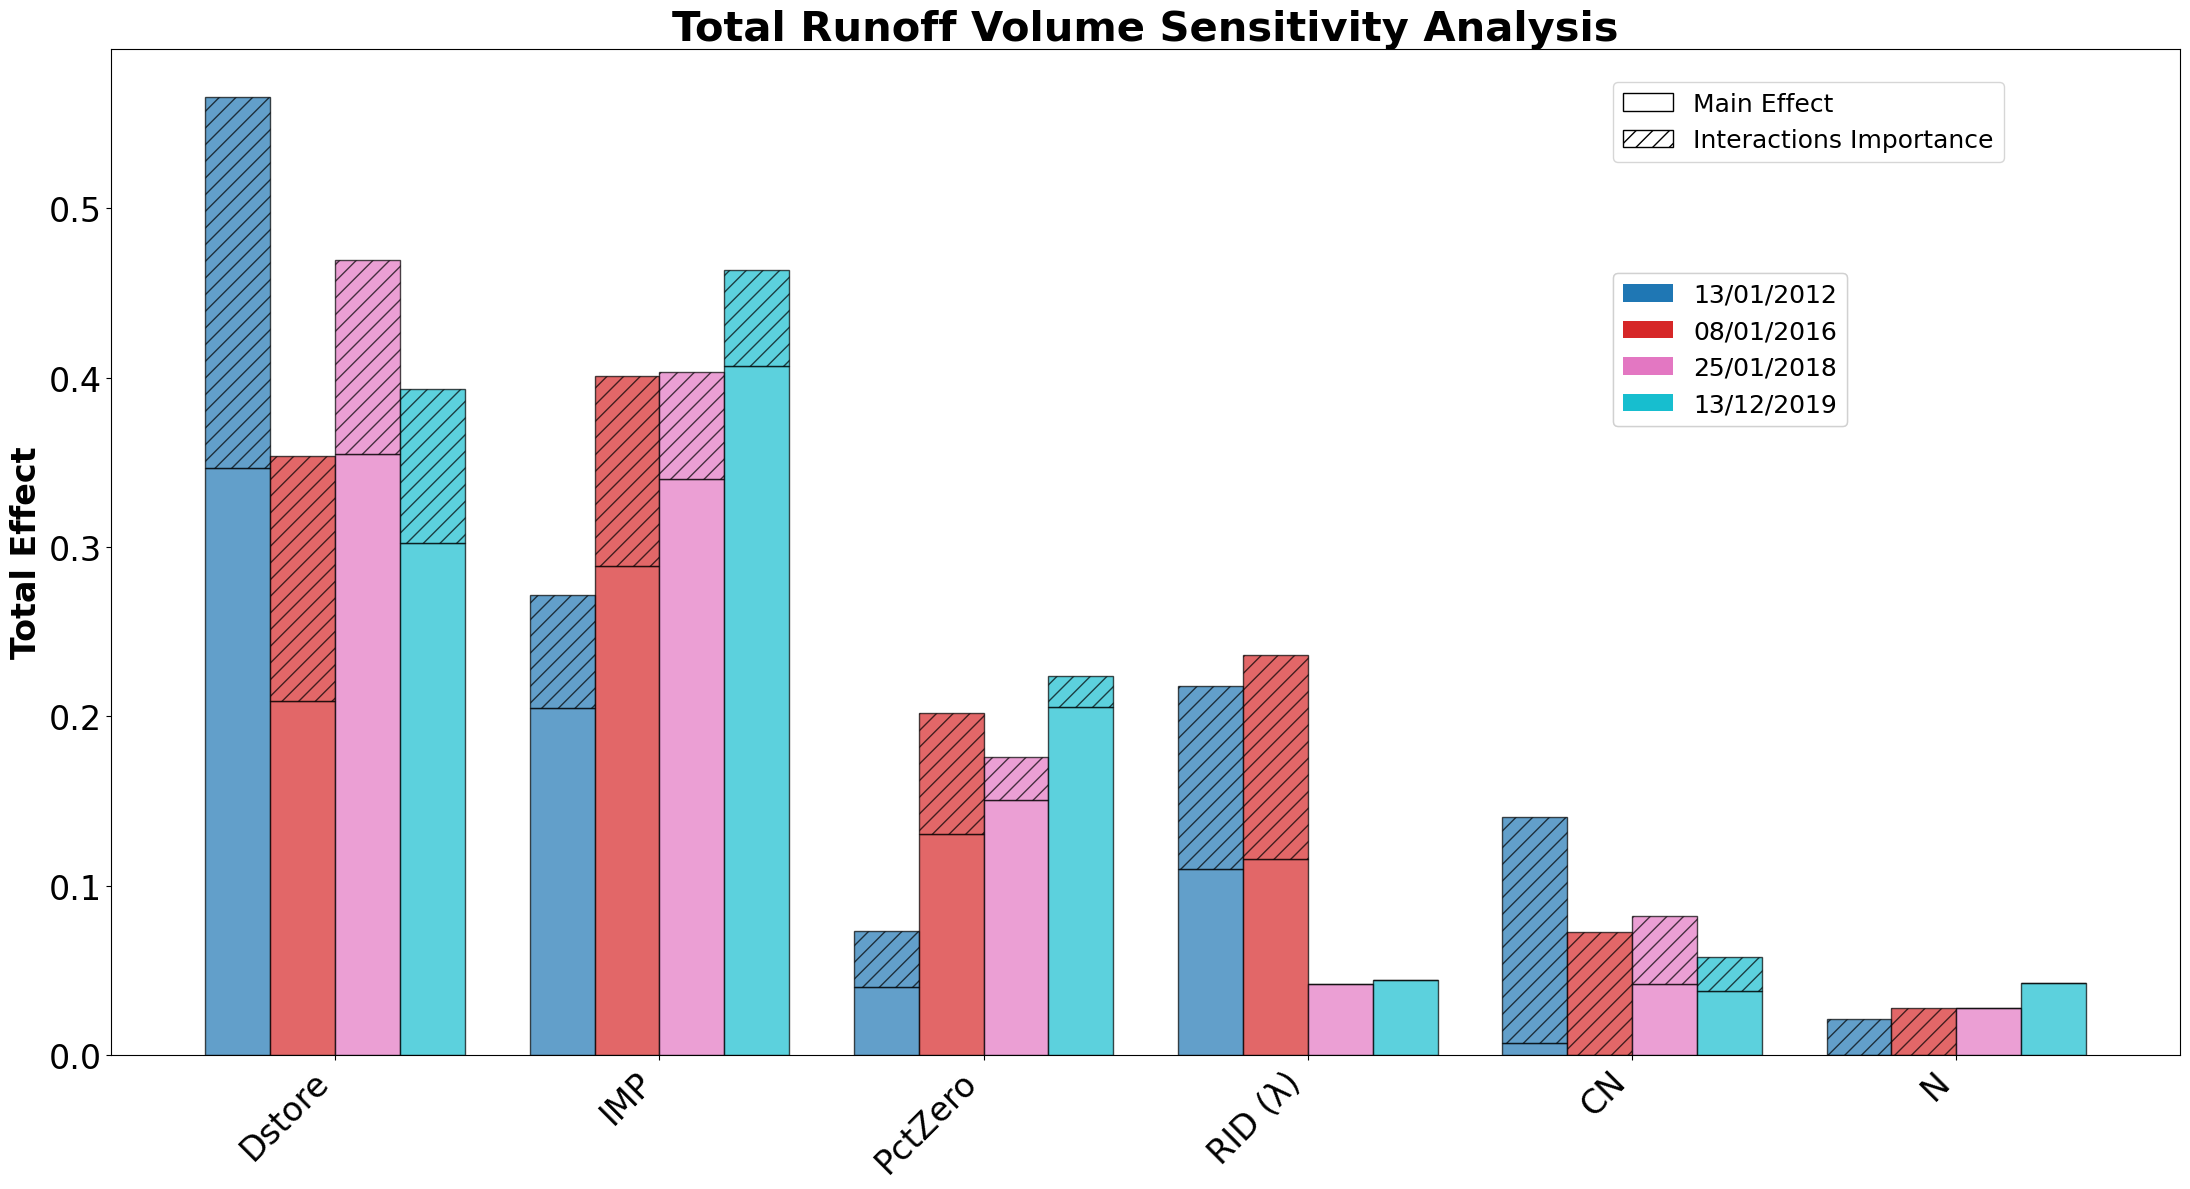

Processed 2012_01_13: 10000 iterations
Processed 2016_01_08: 10000 iterations
Processed 2018_01_25: 10000 iterations
Processed 2019_12_13: 10000 iterations


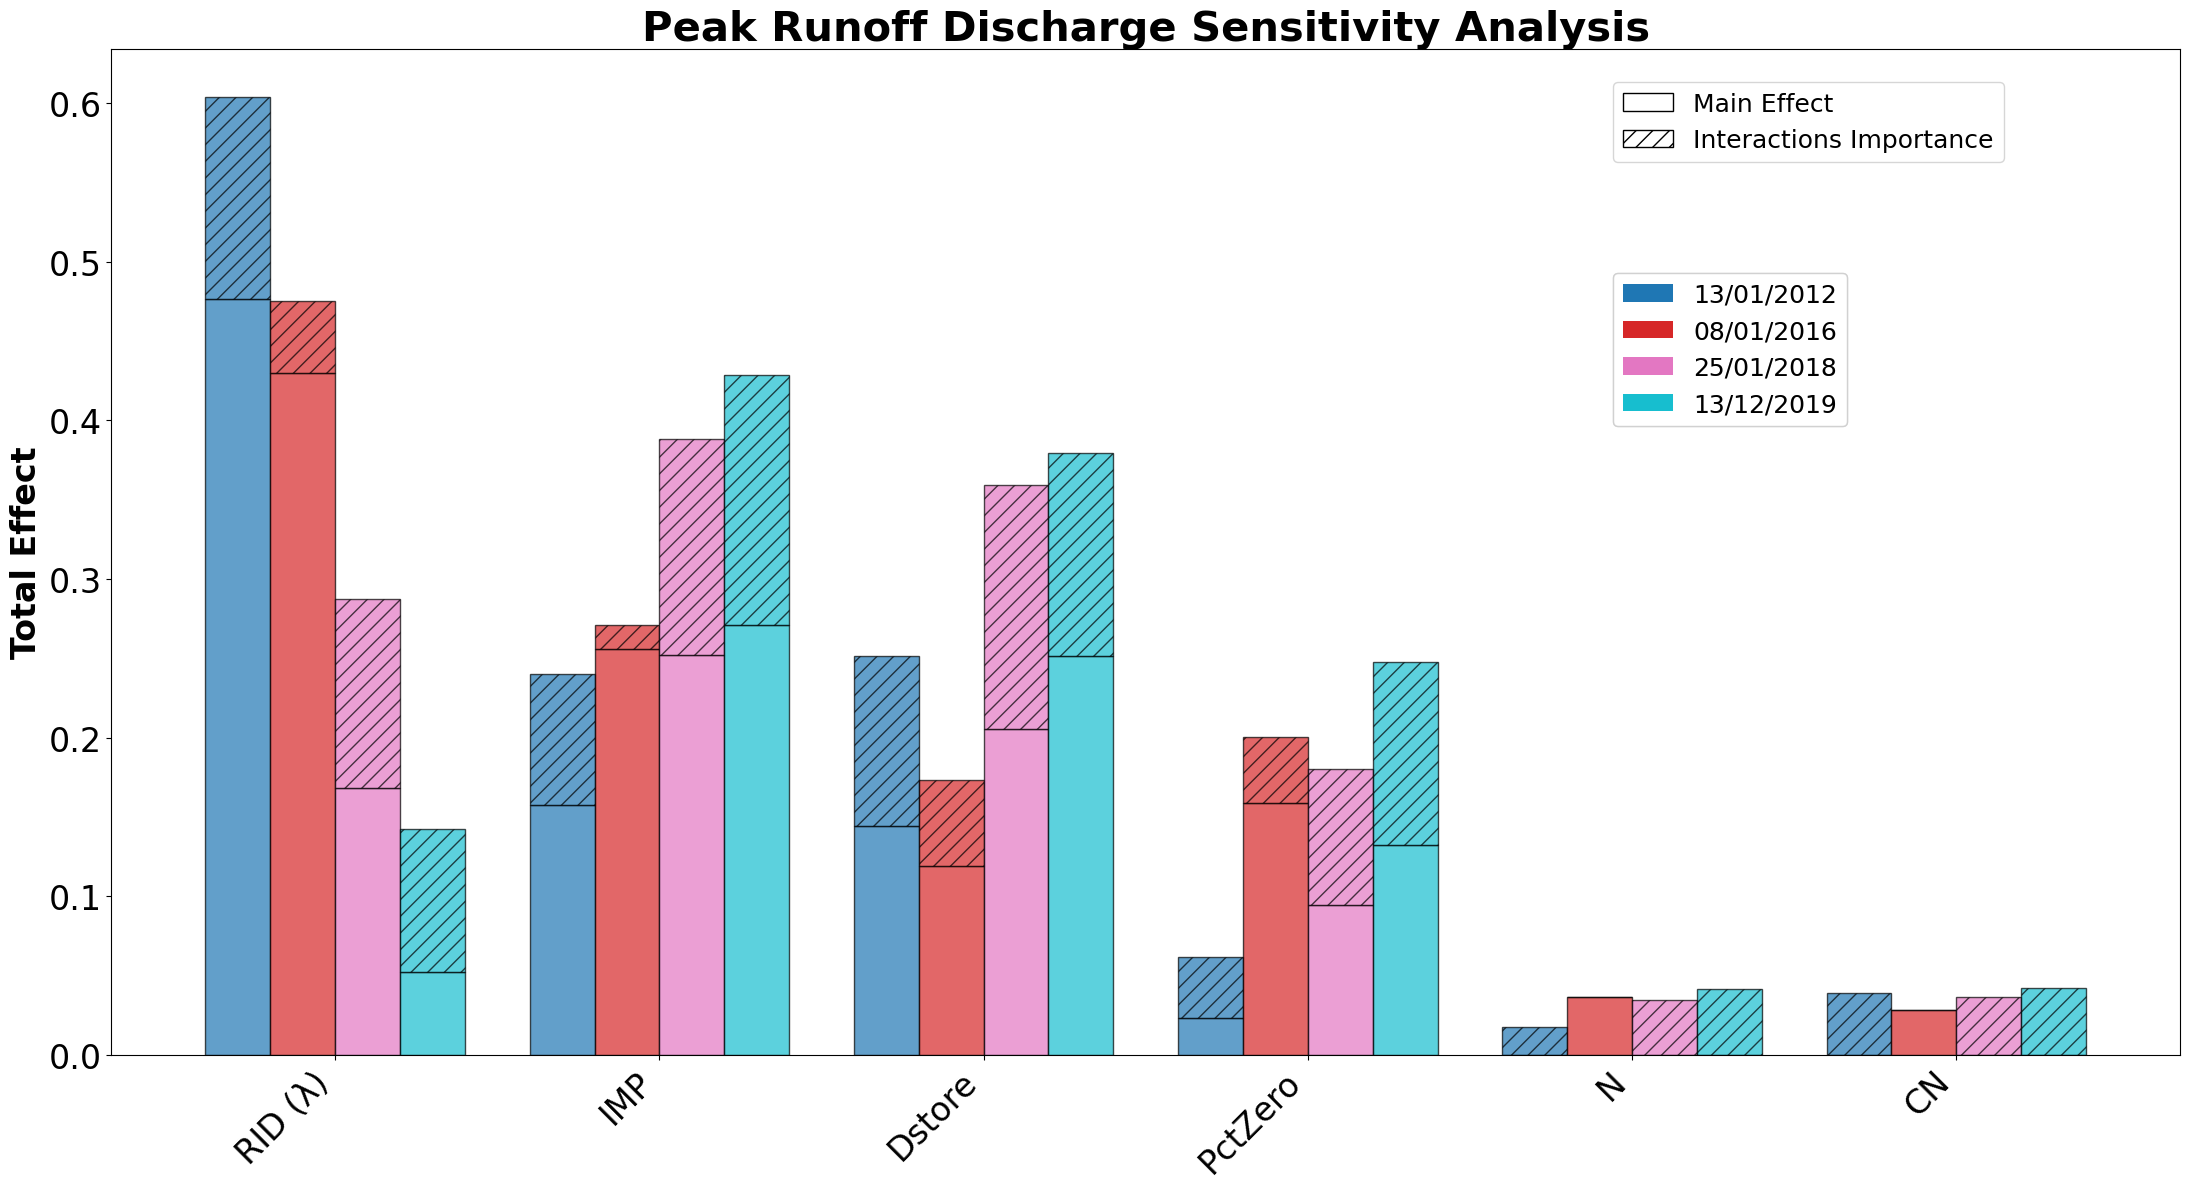

In [4]:
# Process outputs and generate bar plots
for output_type in output_types:
    process_output(output_type)

In [9]:
def generate_min_max_median_plot(combined_data):
    """
    Generate combined min-max and median plot ordered by average medians.
    """
    title_mapping = {
        'total_outflow': 'Total volume',
        'max_outflow': 'Peak discharge'
    }

    avg_medians = {
        param: np.mean([np.median(combined_data[output_type][param]) for output_type in combined_data])
        for param in parameters
    }
    sorted_parameters_by_median = sorted(avg_medians, key=avg_medians.get, reverse=True)
    updated_labels_by_median = [parameter_label_mapping[param] for param in sorted_parameters_by_median]

    fig, ax = plt.subplots(figsize=(12, 6))
    offset = 0.2
    index = np.arange(len(sorted_parameters_by_median))

    for output_idx, output_type in enumerate(combined_data.keys()):
        data = combined_data[output_type]
        for i, param in enumerate(sorted_parameters_by_median):
            x_pos = i + (offset * output_idx)
            min_val = np.min(data[param])
            max_val = np.max(data[param])
            median_val = np.median(data[param])
            
            ax.plot([x_pos, x_pos], [min_val, max_val], color='black', linewidth=1,
                    label='Min-Max range' if output_idx == 0 and i == 0 else "")
            ax.plot(x_pos, median_val, 'o', color=colors[output_type], markersize=10,
                    label=title_mapping[output_type] if i == 0 else "")

#     ax.set_title('Variance Based Sensitivity Analysis\n4 Event Based', fontsize=30, fontweight='bold')
    ax.set_ylabel('Variance based  \ntotal effect', fontsize=18)
    ax.set_xticks(index + offset / 2)
    ax.set_xticklabels(updated_labels_by_median, rotation=45, fontsize=18, ha='right')
    ax.tick_params(axis='y', labelsize=18)
    ax.tick_params(axis='x', labelsize=18)
    ax.legend(fontsize=18, loc='upper right', bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_output_path_base, 'VB_combined_min_max_medians.png'), dpi=300, bbox_inches='tight')
    plt.show()


In [12]:
# Generate Min-Max and Median Plot
generate_min_max_median_plot(combined_data)

TypeError: generate_min_max_median_plot() missing 1 required positional argument: 'fig_output_path_base'